## --- Generate text with a recurrent neural network (Pytorch) ---
### (Mostly Read & Run)

The goal is to replicate the (famous) experiment from [Karpathy's blog](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

To learn to generate text, we train a recurrent neural network to do the following task:

Given a "chunk" of text: `this is random text`

the goal of the network is to predict each character in **`his is random text` ** sequentially given the following sequential input **`this is random tex`**:




## Load text (dataset/input.txt)

Before building training batch, we load the full text in RAM

In [13]:
# !wget https://thome.isir.upmc.fr/classes/RITAL/input.txt

In [14]:
# ! pip install unidecode

In [15]:
import unidecode
import string
import random
import re
import torch
import torch.nn as nn

all_characters = string.printable
n_characters = len(all_characters)

file = unidecode.unidecode(open('./input.txt').read()) #clean text => only ascii
file_len = len(file)
print('file_len =', file_len)


file_len = 1115394


## 2: Helper functions:

We have a text and we want to feed batch of chunks to a neural network:

one chunk  A,B,C,D,E
[input] A,B,C,D -> B,C,D,E [output]

Note: we will use an embedding layer instead of a one-hot encoding scheme.

for this, we have 3 functions:

- One to get a random str chunk of size `chunk_len` : `random_chunk`
- One to turn a chunk into a tensor of size `(1,chunk_len)` coding for each characters : `char_tensor`
- One to return random input and output chunks of size `(batch_size,chunk_len)` : `random_training_set`




In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [17]:
import time, math


#Get a piece of text
def random_chunk(chunk_len):
    start_index = random.randint(0, file_len - chunk_len)
    end_index = start_index + chunk_len + 1
    return file[start_index:end_index]


# Turn string into list of longs
def char_tensor(string):
    tensor = torch.zeros(1, len(string), dtype=torch.long, device=device)
    for c in range(len(string)):
        tensor[0, c] = all_characters.index(string[c])
    return tensor


#Turn a piece of text in train/test
def random_training_set(chunk_len=200, batch_size=8):
    chunks = [random_chunk(chunk_len) for _ in range(batch_size)]
    inp = torch.cat([char_tensor(chunk[:-1]) for chunk in chunks], dim=0)
    target = torch.cat([char_tensor(chunk[1:]) for chunk in chunks], dim=0)
    return inp, target

print(random_training_set(10,4))  ## should return 8 chunks of 10 letters.

(tensor([[22, 14, 94, 29, 24, 94, 28, 17, 27, 18],
        [94, 21, 30, 28, 29, 15, 30, 21, 94, 14],
        [12, 14, 94, 24, 15, 94, 13, 18, 31, 18],
        [96, 43, 14, 94, 11, 14, 94, 10, 28, 94]], device='cuda:0'), tensor([[14, 94, 29, 24, 94, 28, 17, 27, 18, 15],
        [21, 30, 28, 29, 15, 30, 21, 94, 14, 34],
        [14, 94, 24, 15, 94, 13, 18, 31, 18, 23],
        [43, 14, 94, 11, 14, 94, 10, 28, 94, 22]], device='cuda:0'))


## The actual RNN model (only thing to complete):

It should be composed of three distinct modules:

- an [embedding layer](https://pytorch.org/docs/stable/nn.html#embedding) (n_characters, hidden_size)

```
nn.Embedding(len_dic,size_vec)
```
- a [recurrent](https://pytorch.org/docs/stable/nn.html#recurrent-layers) layer (hidden_size, hidden_size)
```
nn.RNN(in_size,out_size) or nn.GRU() or nn.LSTM() => rnn_cell parameter
```
- a [prediction](https://pytorch.org/docs/stable/nn.html#linear) layer (hidden_size, output_size)

```
nn.Linear(in_size,out_size)
```
=> Complete the `init` function code

In [18]:
import torch.nn.functional as f
from torch import nn


class RNN(nn.Module):

    def __init__(self, n_char, hidden_size, output_size, n_layers=1, rnn_cell=nn.RNN):
        """
        Create the network
        """
        super(RNN, self).__init__()

        self.n_char = n_char
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        #  (batch,chunk_len) -> (batch, chunk_len, hidden_size)
        self.embed = nn.Embedding(n_char, hidden_size)

        # (batch, chunk_len, hidden_size)  -> (batch, chunk_len, hidden_size)
        self.rnn = rnn_cell(
            num_layers=n_layers, input_size=hidden_size, hidden_size=hidden_size
        )

        # (batch, chunk_len, hidden_size) -> (batch, chunk_len, output_size)
        self.predict = nn.Linear(hidden_size, output_size)

    def forward(self, input):
        """
        batched forward: input is (batch > 1,chunk_len)
        """
        input = self.embed(input)
        output, _ = self.rnn(input)
        output = self.predict(f.tanh(output))
        return output

    def forward_seq(self, input, hidden=None):
        """
        not batched forward: input is  (1,chunk_len)
        """
        input = self.embed(input)
        output, hidden = self.rnn(input.unsqueeze(0), hidden)
        output = self.predict(f.tanh(output))
        return output, hidden

## Text generation function

Sample text from the model

In [19]:
def generate(model, prime_str="A", predict_len=100, temperature=0.8):
    prime_input = char_tensor(prime_str).squeeze(0).to(device)
    hidden = None
    predicted = prime_str

    for p in range(len(prime_str) - 1):
        _, hidden = model.forward_seq(prime_input[p].unsqueeze(0), hidden)

    for p in range(predict_len):
        output, hidden = model.forward_seq(prime_input[-1].unsqueeze(0), hidden)
        output_dist = output.data.view(-1).div(temperature).exp()
        top_i = torch.multinomial(output_dist, 1)[0]
        predicted_char = all_characters[top_i]
        predicted += predicted_char
        prime_input = torch.cat(
            [prime_input, char_tensor(predicted_char).squeeze(0)]
        )

    return predicted

## Training loop for net

In [20]:
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return "%dm %ds" % (m, s)


###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 80

####

model = RNN(n_characters, hidden_size, n_characters, n_layers).to(device)  # create model
model_optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # create Adam optimizer
criterion = nn.CrossEntropyLoss()  # chose criterion

start = time.time()
all_losses = []
loss_avg = 0


def train(inp, target):
    """
    Train sequence for one chunk:
    """
    # reset gradients
    model_optimizer.zero_grad()

    # predict output
    output = model(inp)

    # compute loss
    loss = criterion(output.view(batch_size * chunk_len, -1), target.view(-1))

    # compute gradients and backpropagate
    loss.backward()
    model_optimizer.step()

    return loss.data.item()


for epoch in range(1, n_epochs + 1):
    loss = train(*random_training_set(chunk_len, batch_size))  # train on one chunk
    loss_avg += loss

    if epoch % print_every == 0:
        print(
            "[%s (%d %d%%) %.4f]"
            % (time_since(start), epoch, epoch / n_epochs * 100, loss)
        )
        print(generate(model, "Wh", 100), "\n")

    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0

 4s (100 0%) 3.0519]
Wh,he heMNrt tidh
: s nT h c nlys m h d tk ne s 'dan tef d tiwot' nm l tithoh
 narEdesin neeLd v
vuen  

 9s (200 1%) 2.8885]
Whles nn
sor meh nahh fi r soum ? lo  l, thedhe th useodis tome Rso r o won
de ndlot, s heounamehe s c 

 14s (300 1%) 2.8095]
Whoromirlere mos  IRnced keI
 t me ulay fothoaneghede  ale, rdab t u,
SUTh; ti re hePnd thor,
 r he: w 

 18s (400 2%) 2.7162]
Wh't hisif udeg! ryuwhath r smaren us s nme  whateoc nit whd awimeop.
UViar stherheUAA ns at theBos,
s 

 24s (500 2%) 2.6158]
Whe ry nd t me gsred, IWhedese.
 warimeanardr k tth uthe vinave Rn tentey anobe s chare, kegtha n.
des 

 28s (600 3%) 2.7075]
Whtr tsed.
I:
I matoge sellrnd he jege she ghearlodsek ab uus wameedeinel senghe thathel
 he mwinsotho 

 33s (700 3%) 2.7119]
Whaundevatr, me mothe: lothey nathe t, the rthas IAWin'lithy,
AOLSA
ee be t yis es fan d.
REHA:
-e thi 

 38s (800 4%) 2.6354]
Whergh IUedis luuste thirorenthonouath y molauogrde ct pet mal tonteee onrlin fthile fogh m

RuntimeError: Sizes of tensors must match except in dimension 0. Expected size 80 but got size 79 for tensor number 2 in the list.

## Visualize loss

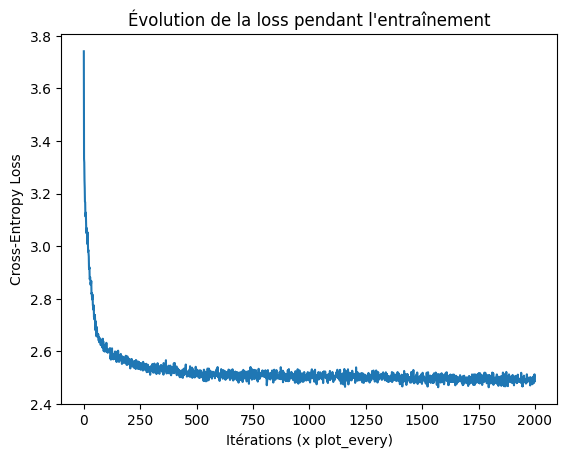

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

plt.figure()
plt.plot(all_losses)
plt.xlabel("Itérations (x plot_every)")
plt.ylabel("Cross-Entropy Loss")
# plt.yscale("log")
plt.title("Évolution de la loss pendant l'entraînement")
plt.show()

## Try different temperatures

Changing the distribution sharpness has an impact on character sampling:

more or less probable things are sampled

In [ ]:
print(generate(model,'T', 200, temperature=1))
print("----")
print(generate(model,'Th', 200, temperature=0.8))
print("----")

print(generate(model,'Th', 200, temperature=0.5))
print("----")

print(generate(model,'Th', 200, temperature=0.3))
print("----")

print(generate(model,'Th', 200, temperature=0.1))

Therede bet:

Bugh thie twn fo S:

Oute dere cimor lit de parantimbespraimolde pppen bav thy ha cthe TIORAndid dayex wis G by PNOoure t,

Snd, p o beeprdearier IORETONIsaid orixbanobouce?
QR:
Fo in asc
----
Therorerever, t t he go wwis t bencere.
An ktcou ored t!

We it there we sethent ayss Beisend mau po bre athabllourmertlliouthal s, aland t per I n stomhe he wes tar oty,
Tot s hey tr, ly for she thanco
----
The the mat I t bere d t d m thathe see wat therer fo t t t mucoorendin tare I anche me d t t asthe ir te thisoure the t t y mul ond my youthe t tou that thand the hes ane tonerathen chathin the t lou t
----
The the the the t t ce he the the s the t the the t he the tout t t t thour t the the the t the t the t t there tous t me at t the t t the t t the t t the the the t t d wind t there ir ou the the thone 
----
The the the the the t the t the the t t t t the t t the the the the the t t t t t t the the t t t t t t the the the the the the the t the t the t the t t the the the the

### Improving this code:

(a) Tinker with parameters:

- Is it really necessary to have 100 dims character embeddings
- Chunk length can be gradually increased
- Try changing RNN cell type (GRUs - LSTMs)

(b) Add GPU support to go faster


In [ ]:
###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 80

####

model = RNN(n_characters, hidden_size, n_characters, n_layers, nn.LSTM).to(device)  # create model
model_optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # create Adam optimizer
criterion = nn.CrossEntropyLoss()  # chose criterion

start = time.time()
all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    loss = train(*random_training_set(chunk_len, batch_size))  # train on one chunk
    loss_avg += loss

    if epoch % print_every == 0:
        print(
            "[%s (%d %d%%) %.4f]"
            % (time_since(start), epoch, epoch / n_epochs * 100, loss)
        )
        print(generate(model, "Wh", 100), "\n")

    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0

plt.figure()
plt.plot(all_losses)
plt.xlabel("Itérations (x plot_every)")
plt.ylabel("Cross-Entropy Loss")
plt.yscale("log")
plt.title("Évolution de la loss pendant l'entraînement")
plt.show()

 5s (100 0%) 3.2932]
Whe ,sfru Ntseeont m rrieAiiuet  sRneurre ToGecc  aeeetSanma nntd  mttepyh sosun
a eanlhflfdiNehr
 ;Or 

 10s (200 1%) 3.2565]
Whea;h h r eI dgiatreeet btdc.Uor
eerusa,et t
omf,oWu bso
 ieoe
  fruetoes oee r  rsel tdrI o ror ,awe 

 15s (300 1%) 3.1191]
Whaeu  ume ea ee ts od aen tdi cwtnw,

eara i e t.CE
hst d i eno h  ra ereatiesmddrtoo  e oneaiusboog, 

 20s (400 2%) 2.9221]
Wheiseost t:ise dil n d BE pkirre de
U, tofes,


I

E brre we
O

eth tosab b t, t,

NR
ALotinley neeeo 

 25s (500 2%) 2.8626]
Whe rheearinshenle uovotRT w ns;:
e fes nc usecerpdhe,ht federm ah s c, I cair,
I d t gC::OA n-ur,ot   

 31s (600 3%) 2.8873]
Wh onk got d ndheahof. neoseg
AI meap sede ot f s hd   t cotiaulolar t as, tithhedot n e nomh hirathau 

 36s (700 3%) 2.8068]
Whhthy deeomt hlheeral es vecis ls: il
:n t me le at t noc? thdan u me re r un the miis aw we rth y so 

 41s (800 4%) 2.7717]
Wh t h whinr
ow lisrl mei l at ame, keo, , iusos  vithit t t iur set I w menarA ased kerrs

KeyboardInterrupt: 